# Comparing multiple tickers

Overlay another ticker's close price on the primary chart to compare relative performance. Merging price series is ordinary data preparation — a join plus an optional rebase — so it is done inline here, in each backend, rather than through a library helper. With both series scaled to the same starting level, relative performance reads directly off the chart.


In [1]:
import yfinance as yf

from mplchart.chart import Chart
from mplchart.primitives import Candlesticks, Volume, LinePlot
from mplchart.utils import normalize_prices

aapl = normalize_prices(yf.Ticker("AAPL").history(period="5y"))
msft = normalize_prices(yf.Ticker("MSFT").history(period="5y"))
aapl.tail(3)


,open,high,low,close,volume,dividends,stock splits
date,,,,,,,
2026-07-22 00:00:00-04:00,327.869995,329.000000,323.339996,325.890015,38755900,0.0,0.0
2026-07-23 00:00:00-04:00,321.730011,323.299988,319.350006,321.660004,40840800,0.0,0.0
2026-07-24 00:00:00-04:00,321.790009,334.369995,321.619995,333.019989,47443900,0.0,0.0


## Merging with pandas

Align the secondary close on the primary index, scale it to the primary's close at the first common date, and assign it as a named column.


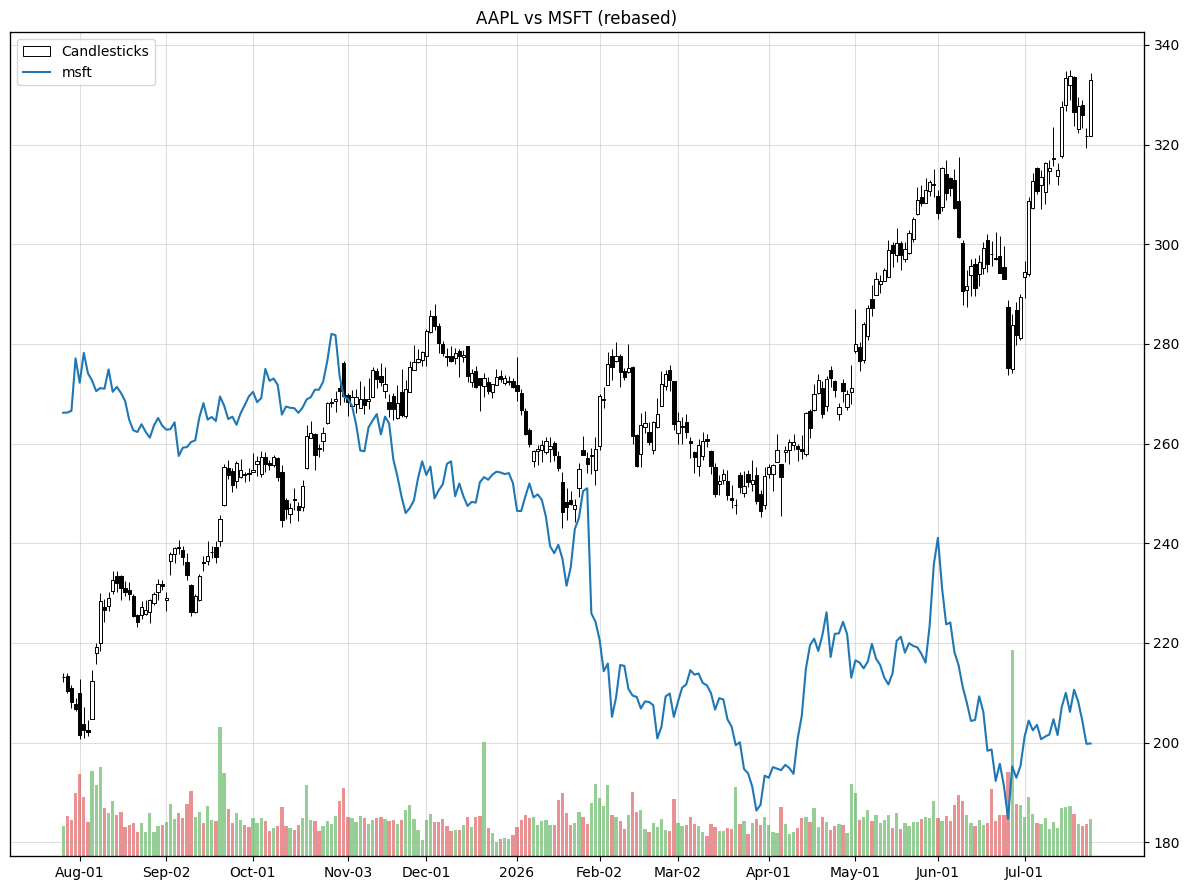

In [2]:
msft_close = msft["close"].reindex(aapl.index)
first = msft_close.first_valid_index()
scale = aapl.loc[first, "close"] / msft_close[first]

prices = aapl.assign(msft=msft_close * scale)

Chart(prices, title="AAPL vs MSFT (rebased)", max_bars=250).plot(
    Candlesticks(), LinePlot("msft"), Volume(),
).show()


## Merging with polars

The same merge in polars: join on the date column, rebase with expressions.


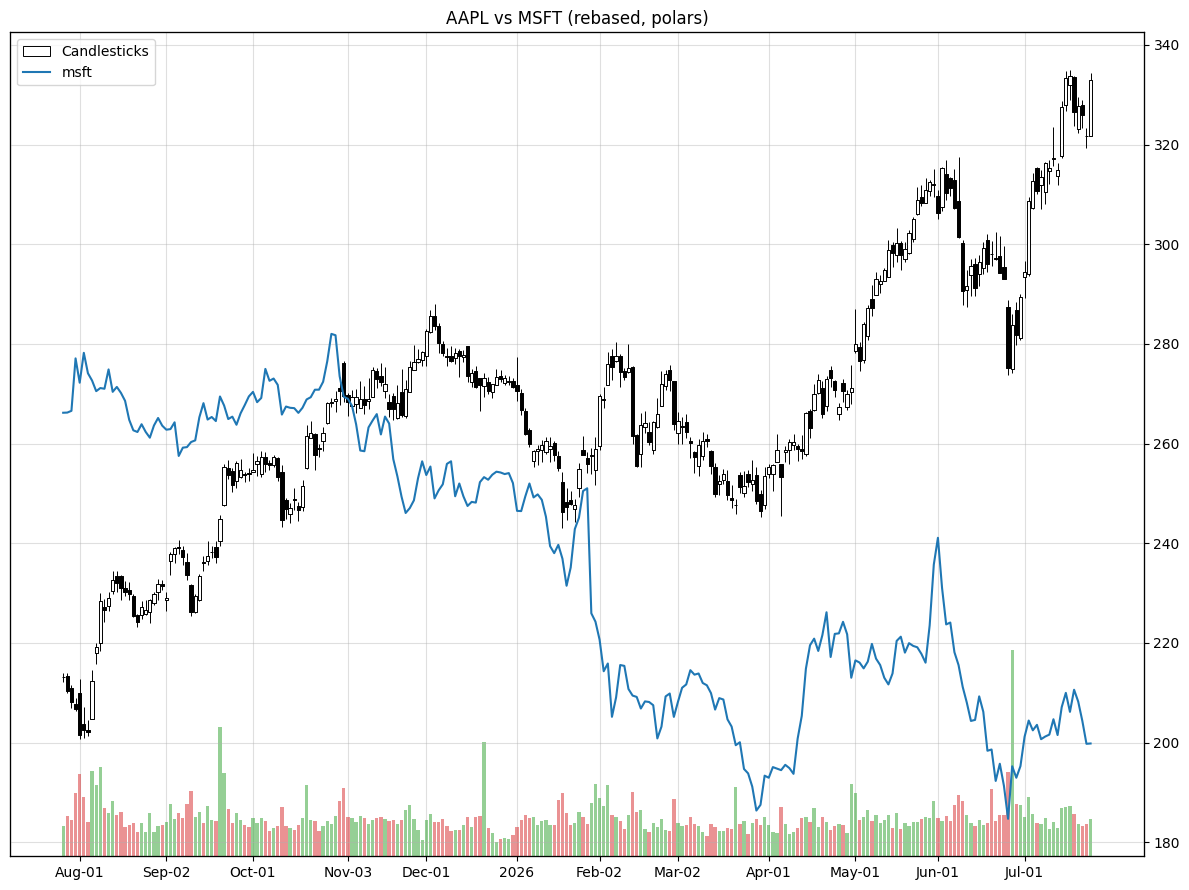

In [3]:
import polars as pl

pl_aapl = pl.from_pandas(aapl.reset_index(names="date"))
pl_msft = pl.from_pandas(msft.reset_index(names="date")).select("date", msft="close")

merged = pl_aapl.join(pl_msft, on="date", how="left")
scale = merged.select((pl.col("close") / pl.col("msft")).drop_nulls().first()).item()
merged = merged.with_columns(pl.col("msft") * scale)

Chart(merged, title="AAPL vs MSFT (rebased, polars)", max_bars=250).plot(
    Candlesticks(), LinePlot("msft"), Volume(),
).show()


The merge is deliberately transparent: close-only, rebased at the first common date. Those are decisions you may want to adapt — resampling mismatched calendars, currency normalization, rebasing at a chosen date — which is why it lives in your code, not the library. (`mplchart.pandas.merge_prices` previously packaged the pandas version and is deprecated.)
